In [422]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import floor
import csv

In [423]:
def sigmoid(inpLst):
    return 1/(1+np.exp(-inpLst))
def ReLU(x_):
    return x_ if x_ > 0 else 0
def np_ReLU(x_):
    return np.maximum(0,x_)
def softmax(x_):
    return np.exp(x_ - np.max(x_, keepdims=True)) / np.sum(np.exp(x_ - np.max(x_, keepdims=True)), keepdims=True)

In [ ]:
class neuronCell:#神经元（单层）
    def __init__(self,inpDim_,optDim_):
        self.inputDim=inpDim_
        self.outputDim=optDim_
        self.weights = np.random.randn(inpDim_, optDim_) * np.sqrt(2.0 / inpDim_)
        self.b = np.zeros((1, optDim_))
        #参数
        self.x = None   #输入
        self.y = None   #矩阵乘法结果
        self.z = None   #输出
        self.dx = None  #梯度输入
        self.dw = None  #梯度权重
        self.db = None  #梯度偏置

    def vowart(self):
        raise NotImplementedError(f"类{self.__class__.__name__}没有前向传播函数")

    def backwart(self):
        raise NotImplementedError(f"类{self.__class__.__name__}没有后向传播函数")
    
    def meanSquareError(self, target_,average=True):#均方差/平方和误差
        diff = self.z - target_
        N = self.z.shape[0]
        if average:
            loss = np.sum(diff**2) / N
            dout = 2 * diff / N
        else:
            loss = np.sum(diff**2)
            dout = 2 * diff
        return loss, dout
    
    def clear(self):
        self.x = None
        self.z = None
        self.dx = None
        self.dw = None
        self.db = None

class linCell(neuronCell):#线性神经元
    def __init__(self,inpDim_,optDim_):
        super().__init__(inpDim_,optDim_)

    def vowart(self, inp_):
        inp_ = np.array(inp_)
        if inp_.ndim == 1:
            if inp_.size % self.inputDim != 0:
                raise ValueError(f"输入元素个数 {inp_.size} 无法整除输入维度 {self.inputDim}")
            inp_ = inp_.reshape(-1, self.inputDim)
        self.x = inp_
        self.z = np.dot(inp_, self.weights) +self.b
        #print(f"输入形状: {inp_.shape}")
        #print(f"z形状: {self.z.shape}")
        return self.z

    def backwart(self, inp_):
        self.dw = np.dot(self.x.T, inp_)
        self.db = np.sum(inp_, axis=0, keepdims=True)
        self.dx = np.dot(inp_, self.weights.T)
        #print(f"输入形状: {inp_.shape}")
        #print(f"z形状: {self.dx.shape}")
        return self.dx
    
    def meanSquareError(self, target_,average=True):
        if target_.ndim == 1:
            target_ = target_.reshape(-1, 1)
        return super().meanSquareError(target_,average)
    
class ActivationCell:#激活层
    def __init__(self):
        self.x = None
        self.z = None
        self.dx = None

    def vowart(self, inp_):
        raise NotImplementedError

    def backwart(self, dout):
        raise NotImplementedError

    def clear(self):
        self.x = None
        self.z = None
        self.dx = None

class ReLUCell(ActivationCell):#ReLU激活层
    def vowart(self, inp_):
        self.x = inp_
        self.z = np_ReLU(inp_)
        return self.z

    def backwart(self, dout):
        self.dx = dout * (self.x > 0)
        return self.dx
    
class sigmoidCell(ActivationCell):#sigmoid激活层
    def vowart(self, inp_):
        self.x = inp_
        self.z = sigmoid(inp_)
        return self.z

    def backwart(self, dout):
        local_grad = self.z * (1 - self.z)
        self.dx = dout * local_grad
        return self.dx

class softmaxCell(ActivationCell):#softmax激活层
    def vowart(self, inp_):
        self.x = inp_
        self.z = softmax(inp_)
        return self.z

    def backwart(self, dout):
        p = self.z
        # 计算 sum_j dout_j * p_j，即逐样本的加权和
        sum_dout_p = np.sum(dout * p, axis=1, keepdims=True)
        self.dx = p * (dout - sum_dout_p)
        return self.dx

LAYER_REGISTRY = {
    "linear": linCell,  
    "relu": ReLUCell,
    "sigmoid": sigmoidCell,
    "softmax": softmaxCell
}
class neuralNet:#神经网络   最后一层必须是线性层
    def __init__(self,typeLayers_,inpDims_,optDims_):
        self.layers=[]
        indexx=0
        for i in range(len(typeLayers_)):
            layerName = typeLayers_[i].lower()
            if layerName == "linear":
                self.layers.append(LAYER_REGISTRY[layerName](inpDims_[indexx],optDims_[indexx]))
                indexx+=1
            else:
                self.layers.append(LAYER_REGISTRY[layerName]())
            
    def vowart(self, inp_):
        inp_ = np.array(inp_)
        for layer in self.layers:
            inp_ = layer.vowart(np.array(inp_))
        return inp_

    def backwart(self, inp_):
        for layer in reversed(self.layers):
            inp_ = layer.backwart(np.array(inp_))
        return inp_

    def clear_cache(self):
        for layer in self.layers:
            layer.clear_cache()

    def train(self,inp_, target_,learningRate):#训练逻辑：前向传播，计算损失和输入梯度，反向传播，梯度下降
        predict = self.vowart(inp_)
        loss, dout = self.layers[-1].meanSquareError(target_, average=True)
        self.backwart(dout)
        for layer in self.layers:
            if hasattr(layer, 'weights') and hasattr(layer, 'dw'):
                layer.weights -= learningRate * layer.dw
                layer.b -= learningRate * layer.db
        return loss

    def meanSquareError(self,inp_, target_,average=True):#均方差/平方和误差
        tmp = self.vowart(inp_)
        diff = tmp - target_
        N = tmp.shape[0]
        if average:
            loss = np.sum(diff**2) / N
        else:
            loss = np.sum(diff**2)
        return loss

In [425]:
numCell=50
tmp=neuralNet(["linEar","relu","liNEaR","relu","liNEaR","Relu","liNEaR"],[1,numCell,numCell,numCell],[numCell,numCell,numCell,1])
print(tmp.vowart([[1],[1],[4]]))
print(tmp.backwart(tmp.vowart([[1],[1],[4]])))

[[0.78535518]
 [0.78535518]
 [3.14142071]]
[[0.61678276]
 [0.61678276]
 [2.46713102]]


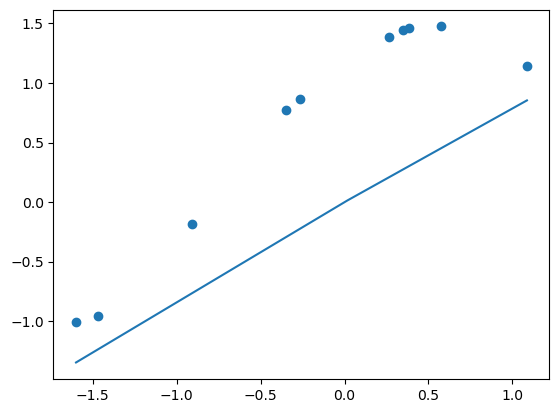

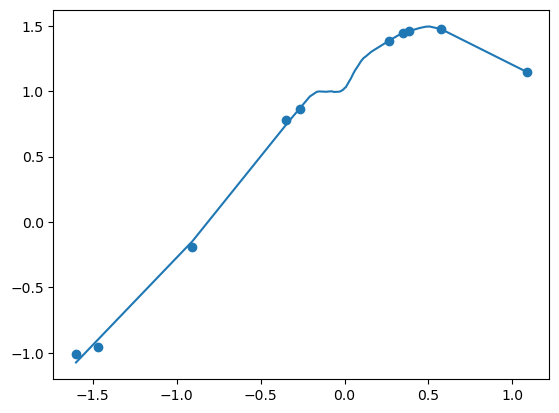

In [426]:
epsilon = 0.001#定义容许误差 Определение допустимой погрешности
maxTime = int(1E5)
alpha = 1E-2
def func(x_):
    return abs(np.sin(x_))+np.cos(2*x_)+np.arctan(x_)

Nn=10
X=np.random.randn(Nn)
Y=func(X)
plotX=np.linspace(min(X),max(X),1000)
plotY=tmp.vowart(plotX)
plt.scatter(X,Y)
plt.plot(plotX,plotY)
plt.show()
for i in range(maxTime):
    lo = tmp.train(X,Y,alpha)
    if(lo<epsilon):
        break
plotY=tmp.vowart(plotX)
plt.scatter(X,Y)
plt.plot(plotX,plotY)
plt.show()